In [2]:
import pandas as pd

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv('train.csv')
df.head()

,id,num_1,num_2,num_3,num_4,num_5,num_6,num_7,num_8,num_9,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7,target
0,0,68,15136,148531,491,80,4,14.98,12,0.55,Bachelor's,Self-employed,Divorced,No,No,Auto,Yes,1
1,1,66,148756,40664,825,16,4,11.32,48,0.25,Bachelor's,Unemployed,Single,Yes,No,Other,No,0
2,2,61,42190,138134,378,5,1,20.50,48,0.79,Bachelor's,Unemployed,Married,Yes,No,Education,Yes,0
3,3,21,89531,33212,558,72,1,14.61,12,0.48,High School,Part-time,Divorced,No,Yes,Auto,Yes,1
4,4,60,36068,72656,659,25,3,7.84,60,0.82,PhD,Part-time,Single,No,Yes,Business,No,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38000 entries, 0 to 37999
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      38000 non-null  int64  
 1   num_1   38000 non-null  int64  
 2   num_2   38000 non-null  int64  
 3   num_3   38000 non-null  int64  
 4   num_4   38000 non-null  int64  
 5   num_5   38000 non-null  int64  
 6   num_6   38000 non-null  int64  
 7   num_7   38000 non-null  float64
 8   num_8   38000 non-null  int64  
 9   num_9   38000 non-null  float64
 10  cat_1   38000 non-null  str    
 11  cat_2   38000 non-null  str    
 12  cat_3   38000 non-null  str    
 13  cat_4   38000 non-null  str    
 14  cat_5   38000 non-null  str    
 15  cat_6   38000 non-null  str    
 16  cat_7   38000 non-null  str    
 17  target  38000 non-null  int64  
dtypes: float64(2), int64(9), str(7)
memory usage: 5.2 MB


In [6]:
df['target'].value_counts()
df['target'].value_counts(normalize=True)

target
0    0.605263
1    0.394737
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()

id        0
num_1     0
num_2     0
num_3     0
num_4     0
num_5     0
num_6     0
num_7     0
num_8     0
num_9     0
cat_1     0
cat_2     0
cat_3     0
cat_4     0
cat_5     0
cat_6     0
cat_7     0
target    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
corr = df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(corr)

target    1.000000
num_7     0.204764
num_3     0.126635
num_6     0.042398
num_9     0.031735
num_8     0.000301
id       -0.000262
num_4    -0.048218
num_2    -0.149350
num_5    -0.150322
num_1    -0.261188
Name: target, dtype: float64


In [10]:
corr = df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(corr)

target    1.000000
num_7     0.204764
num_3     0.126635
num_6     0.042398
num_9     0.031735
num_8     0.000301
id       -0.000262
num_4    -0.048218
num_2    -0.149350
num_5    -0.150322
num_1    -0.261188
Name: target, dtype: float64


In [11]:
#FEATURE ENGINEERING
df['loan_to_income'] = df['num_3'] / (df['num_2'] + 1) #loan / income

df['interest_burden'] = df['num_7'] * df['num_3'] #interest_rate × loan_amount

df['credit_income_ratio'] = df['num_4'] / (df['num_2'] + 1) #interest_rate × loan_amount

In [12]:
TARGET = 'target'

# Drop ID
X = df.drop(columns=[TARGET, 'id'])
y = df[TARGET]

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
num_cols = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_cols = X_train.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
['num_1', 'num_2', 'num_3', 'num_4', 'num_5', 'num_6', 'num_7', 'num_8', 'num_9', 'loan_to_income', 'interest_burden', 'credit_income_ratio']

Categorical Columns:
['cat_1', 'cat_2', 'cat_3', 'cat_4', 'cat_5', 'cat_6', 'cat_7']


In [15]:
# Numerical Pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [20]:
models = {

    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )

}

TRAINING: Logistic Regression

ROC-AUC: 0.7581

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      4600
           1       0.65      0.54      0.59      3000

    accuracy                           0.70      7600
   macro avg       0.69      0.68      0.68      7600
weighted avg       0.70      0.70      0.70      7600



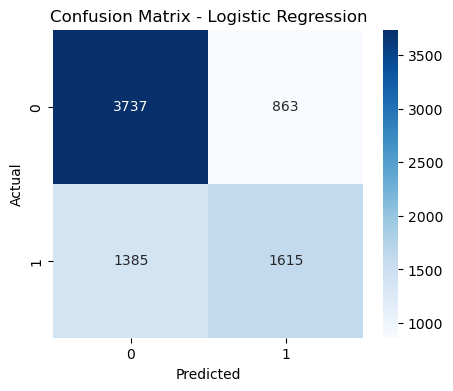

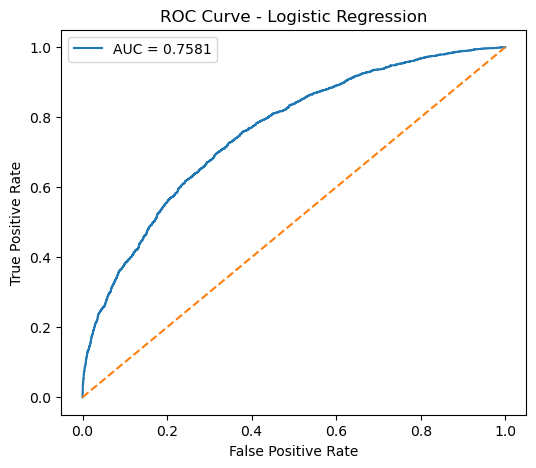

TRAINING: Random Forest

ROC-AUC: 0.7448

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.82      0.77      4600
           1       0.65      0.49      0.56      3000

    accuracy                           0.69      7600
   macro avg       0.68      0.66      0.66      7600
weighted avg       0.69      0.69      0.68      7600



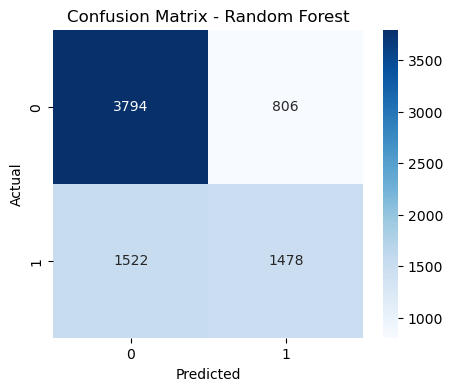

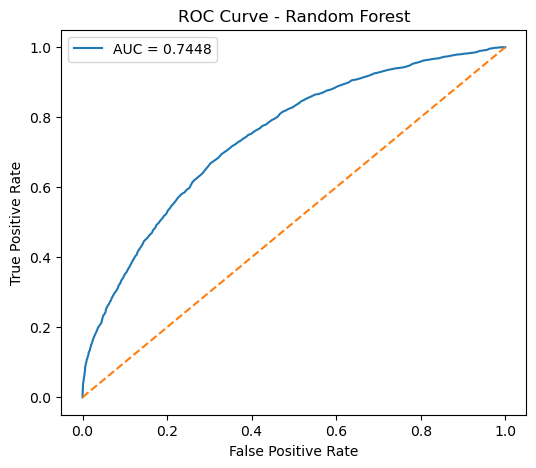

TRAINING: XGBoost

ROC-AUC: 0.7480

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.80      0.76      4600
           1       0.63      0.53      0.58      3000

    accuracy                           0.69      7600
   macro avg       0.68      0.67      0.67      7600
weighted avg       0.69      0.69      0.69      7600



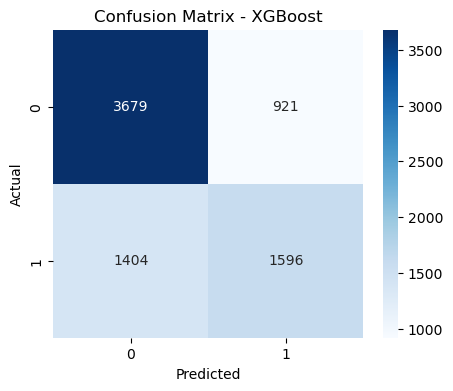

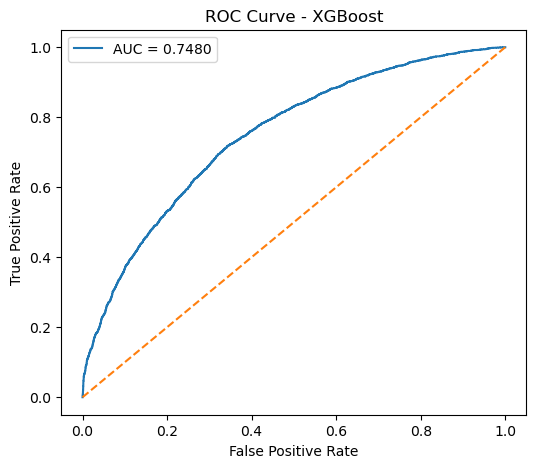

In [21]:
results = []

for model_name, model in models.items():

    print("=" * 60)
    print(f"TRAINING: {model_name}")

    # Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict Probabilities
    y_prob = pipeline.predict_proba(X_valid)[:, 1]

    # Predict Classes
    y_pred = pipeline.predict(X_valid)

    # ROC-AUC
    roc_auc = roc_auc_score(y_valid, y_prob)

    # Save Results
    results.append({
        'Model': model_name,
        'ROC-AUC': roc_auc
    })

    print(f"\nROC-AUC: {roc_auc:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_valid, y_pred))

    # -----------------------------------------------------
    # Confusion Matrix
    # -----------------------------------------------------

    cm = confusion_matrix(y_valid, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # -----------------------------------------------------
    # ROC Curve
    # -----------------------------------------------------

    fpr, tpr, thresholds = roc_curve(y_valid, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1], [0,1], linestyle='--')

    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.legend()

    plt.show()

In [22]:
# =========================================================
# LOGISTIC REGRESSION PIPELINE
# =========================================================

logreg_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', LogisticRegression(
        max_iter=5000,
        random_state=42
    ))

])



# =========================================================
# RANDOM SEARCH PARAMETERS
# =========================================================

param_dist = {
    'model__C': np.logspace(-3, 2, 30),
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']
}


# =========================================================
# RANDOMIZED SEARCH CV
# =========================================================

random_search = RandomizedSearchCV(

    estimator=logreg_pipeline,

    param_distributions=param_dist,

    n_iter=20,

    scoring='roc_auc',

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

In [23]:

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__C': array([1.0000...00000000e+02]), 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear', 'saga']}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [24]:
print("\nBEST PARAMETERS")
print(random_search.best_params_)

print("\nBEST CV ROC-AUC")
print(random_search.best_score_)



BEST PARAMETERS
{'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': np.float64(0.07880462815669913)}

BEST CV ROC-AUC
0.7589210824275362


In [25]:
best_model = random_search.best_estimator_

In [26]:
#VALIDATION PREDICTION
y_prob = best_model.predict_proba(X_valid)[:,1]

y_pred = best_model.predict(X_valid)

In [27]:
#VALIDATION ROC-AUC
roc_auc = roc_auc_score(y_valid, y_prob)

print(f"\nVALIDATION ROC-AUC: {roc_auc:.4f}")


VALIDATION ROC-AUC: 0.7581


In [28]:
print("\nCLASSIFICATION REPORT")
print(classification_report(y_valid, y_pred))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      4600
           1       0.65      0.54      0.59      3000

    accuracy                           0.70      7600
   macro avg       0.69      0.68      0.68      7600
weighted avg       0.70      0.70      0.70      7600



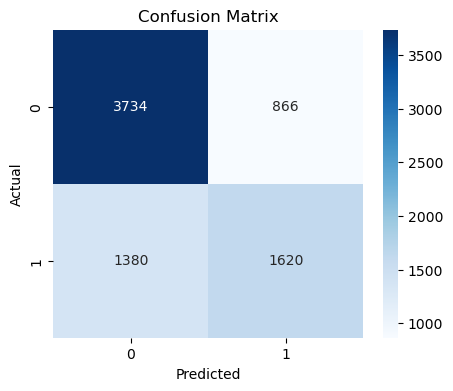

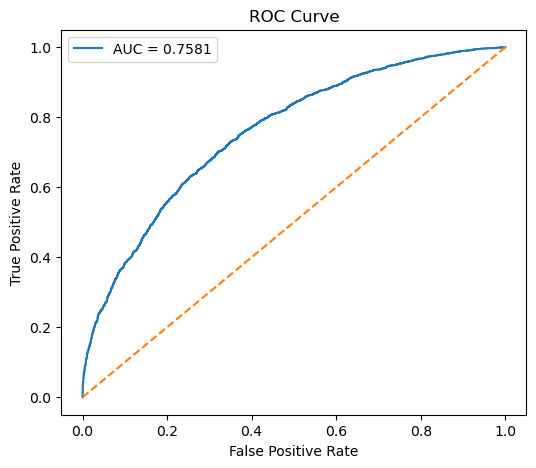

In [29]:

cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()



#roc

fpr, tpr, thresholds = roc_curve(y_valid, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.show()




In [30]:
# =========================================================
# LOAD TEST DATA
# =========================================================

df_test = pd.read_csv('secret_test_features.csv')

# Save ID
test_ids = df_test['id']


# =========================================================
# FEATURE ENGINEERING FOR TEST SET
# =========================================================

df_test['loan_to_income'] = df_test['num_3'] / (df_test['num_2'] + 1)

df_test['interest_burden'] = df_test['num_7'] * df_test['num_3']

df_test['credit_income_ratio'] = df_test['num_4'] / (df_test['num_2'] + 1)


# =========================================================
# PREPARE TEST FEATURES
# =========================================================

X_test = df_test.drop(columns=['id'])


# =========================================================
# TRAIN BEST MODEL USING FULL TRAIN DATA
# =========================================================

# Refit best model on ALL data
best_model.fit(X, y)


# =========================================================
# PREDICT TEST SET
# =========================================================

# Predicted probability
test_prob = best_model.predict_proba(X_test)[:, 1]

# Predicted class
test_pred = best_model.predict(X_test)


# =========================================================
# CREATE SUBMISSION FILE
# =========================================================

submission = pd.DataFrame({
    'id': test_ids,
    'prediction': test_pred,
    'probability': test_prob
})


# =========================================================
# SAVE CSV
# =========================================================

submission.to_csv(
    'randomsearch_predictions.csv',
    index=False,
    encoding='utf-8'
)

print("Successfully created")
print(submission.head())

Successfully created
   id  prediction  probability
0   0           0     0.275676
1   1           1     0.509705
2   2           0     0.252652
3   3           0     0.345653
4   4           0     0.241948
